In [1]:
import os
import json
import numpy as np
import torch
import cv2
from torch_geometric.data import DataLoader
from torch.utils.data import random_split
from deeplsd.models.deeplsd_inference import DeepLSD
import ground_truth.feature_extraction as ft
from ground_truth.visualization import plot_images, plot_coplanar_lines, plot_lines_bool
import matplotlib.pyplot as plt

import torch.nn as nn
import torch_geometric.nn as pyg_nn

from models.dataset_inductive import GraphDatasetInductive
from models.dataset_inference import GraphDatasetInference
from models.model_utils import train_inductive, test_inductive, run_inference

In [2]:
from models.base_gat_combined import GATClassifierCombined


In [3]:
# Paramaeters
image_pth          = 'data/ai_002_001/ai_002_001/images/scene_cam_00_final_preview/frame.0000.color.jpg'
model_pth         = 'model.pth'
# Model parameters
in_channels       = 1280
hidden_channels   = 64
out_channels      = 64
num_layers        = 2
dropout           = 0.1
act               = 'relu'


device            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
model     = GATClassifierCombined(in_channels=in_channels, 
                            hidden_channels=hidden_channels, 
                            out_channels=out_channels, 
                            num_layers=num_layers, 
                            dropout=dropout, 
                            act=act).to(device)

model.load_state_dict(torch.load(model_pth, map_location=device))

<All keys matched successfully>

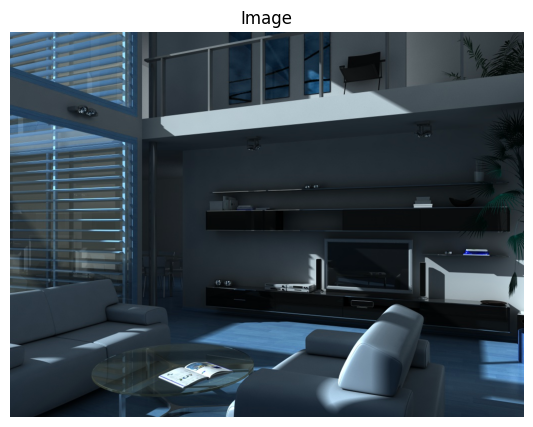

In [5]:
color_img = cv2.imread(image_pth, cv2.IMREAD_UNCHANGED) # Load as is (handles color, grayscale, alpha)
gray_img = cv2.cvtColor(color_img, cv2.COLOR_RGB2GRAY)

plot_images([color_img], ["Image"])

In [6]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
conf = {'detect_lines': True, 'line_detection_params': {'merge': False, 'filtering': True, 'grad_thresh': 3}}
ckpt = torch.load('../weights/deeplsd_md.tar', map_location=device, weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net = net.to(device).eval()
    

In [7]:
df_intermediate_features = None
angle_intermediate_features = None 
df_hook_handle = net.df_head[5].register_forward_hook(ft.hook_df)
angle_hook_handle = net.angle_head[5].register_forward_hook(ft.hook_angle)
input_tensor = torch.tensor(gray_img, dtype=torch.float32, device=device)[None, None] / 255.
with torch.no_grad():
    out = net({'image': input_tensor})
    pred_lines = out['lines'][0]
    if isinstance(pred_lines, torch.Tensor):
        pred_lines = pred_lines.cpu().numpy()
        
# get embeddings for intermediate layers.
combined_features = torch.cat([ft.df_intermediate_features, ft.angle_intermediate_features], dim=1)
downsample_ratio = color_img.shape[1] / combined_features.shape[3]
df_hook_handle.remove()
angle_hook_handle.remove()

In [8]:
embeddings = []
for i, l in enumerate(pred_lines):
    line = l.reshape(2, 2) if l.shape == (4,) else l
    line_embedding = ft.sample_line_features(combined_features, line, num_samples=10, downsample_ratio=downsample_ratio).tolist()
    embeddings.append(line_embedding)

In [9]:
dataset = GraphDatasetInference([embeddings])

In [10]:
node_preds, edge_preds = run_inference(model, dataset, model_path=model_pth, device=device)


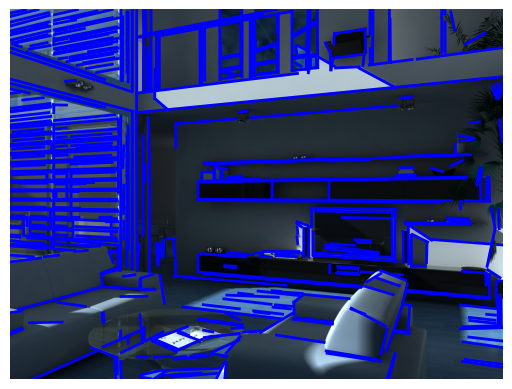

In [11]:
fig, ax = plt.subplots()

plot_lines_bool(ax, color_img, pred_lines, node_preds[0].flatten().tolist())

In [12]:

# Convert to NumPy
edge_preds_array = edge_preds[0].numpy()
print(edge_preds_array.shape)

edge_preds_array = edge_preds_array.reshape((len(pred_lines), -1))
print(edge_preds_array.shape)

(328329, 1)
(573, 573)


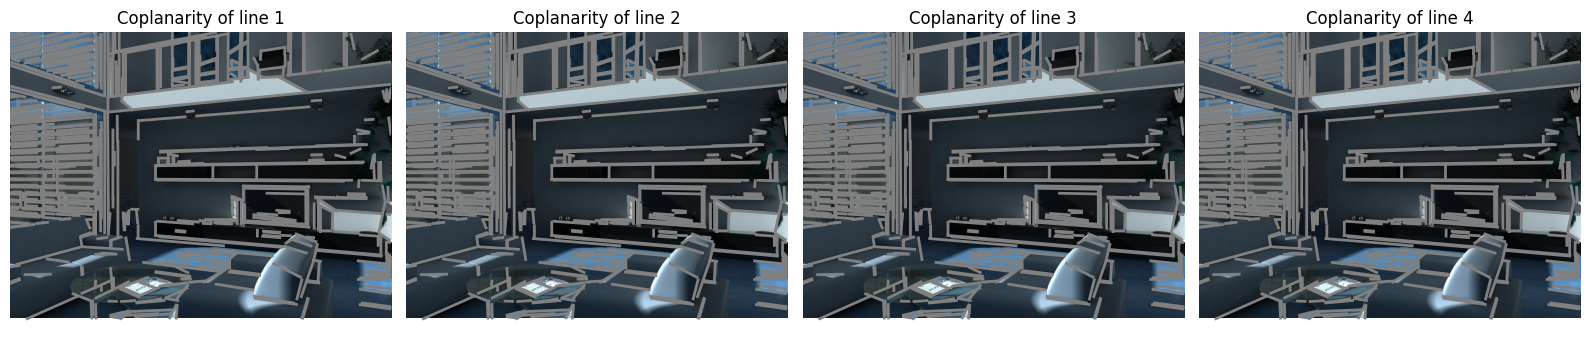

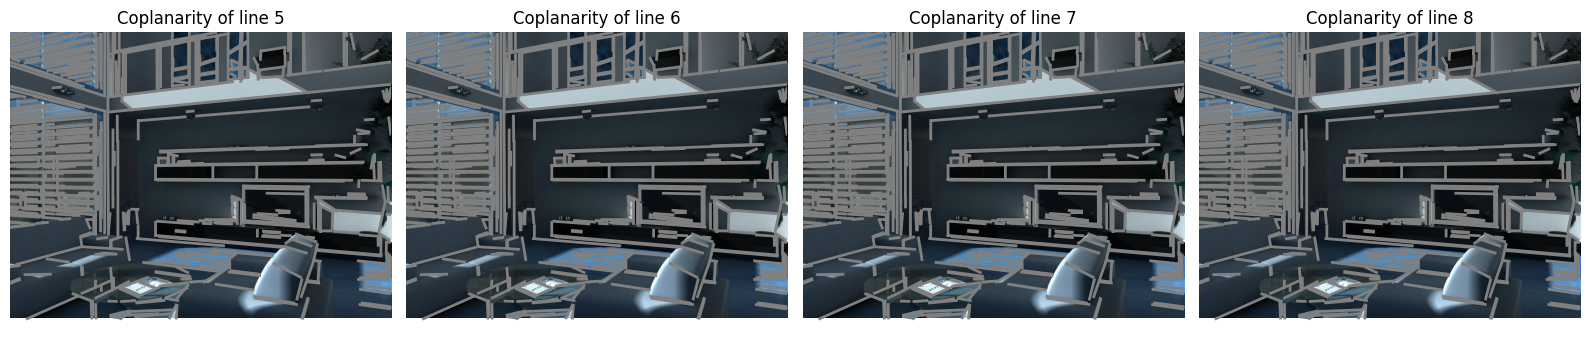

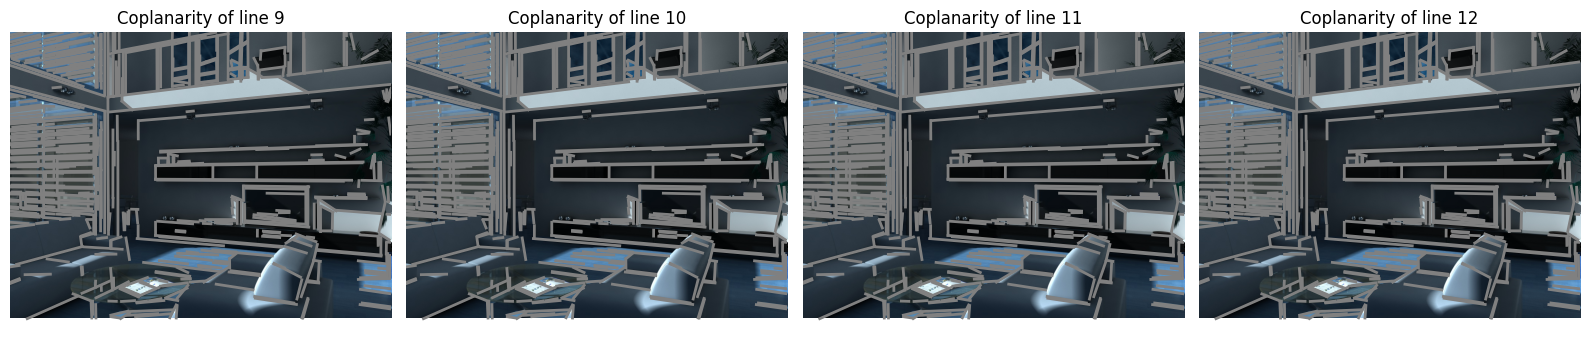

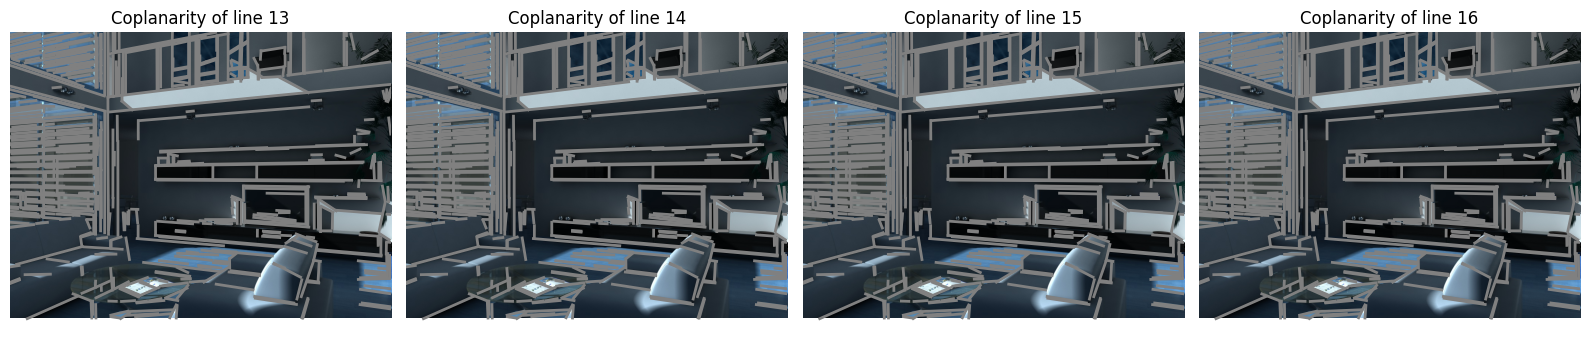

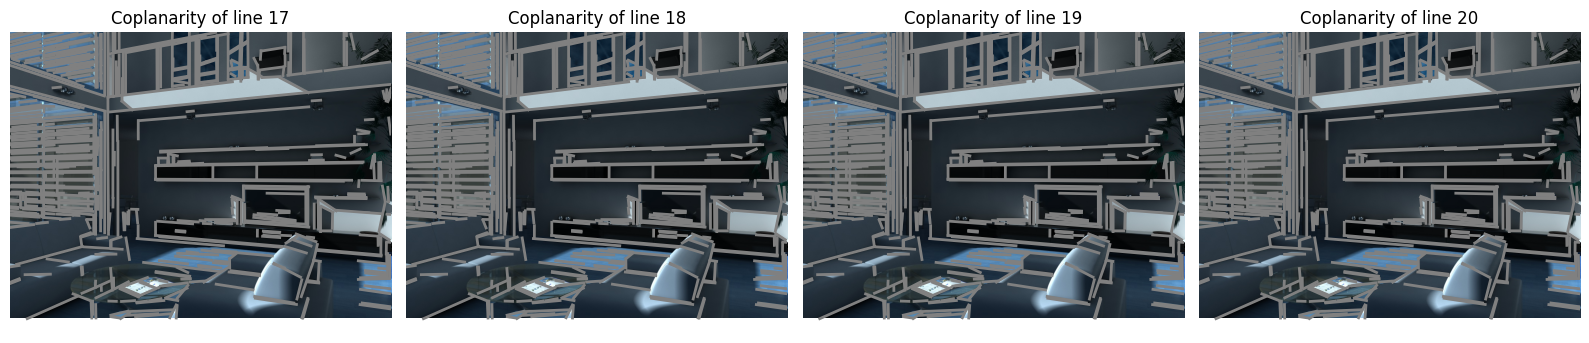

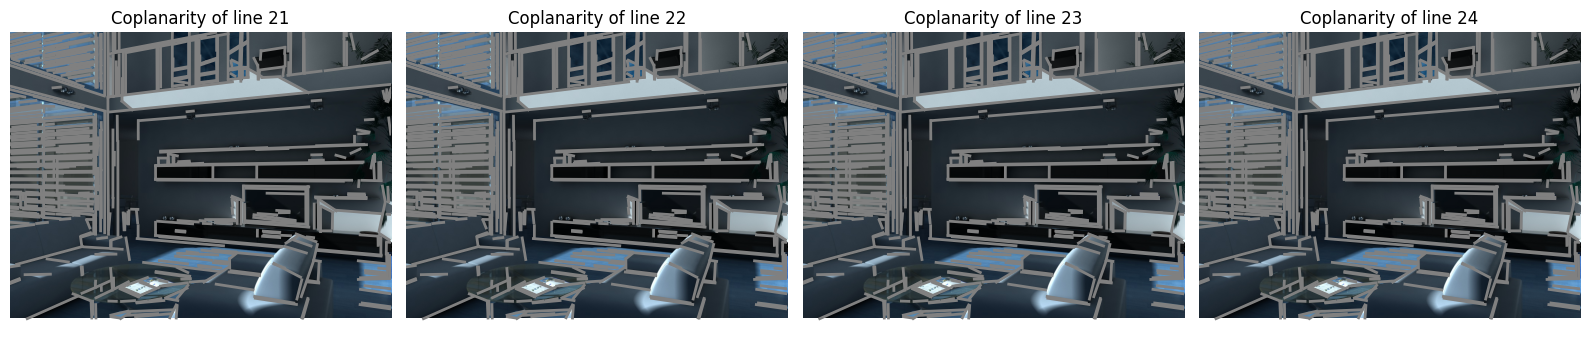

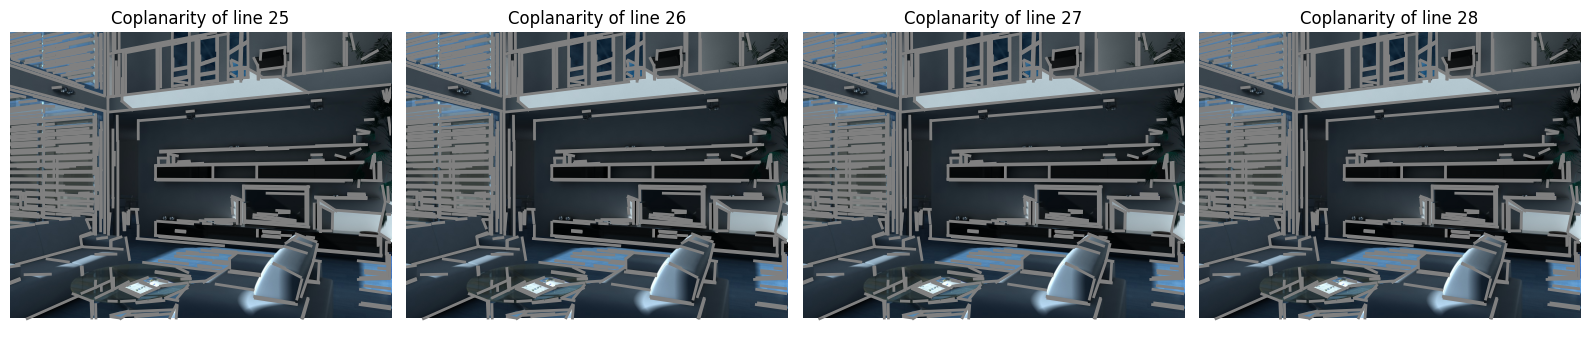

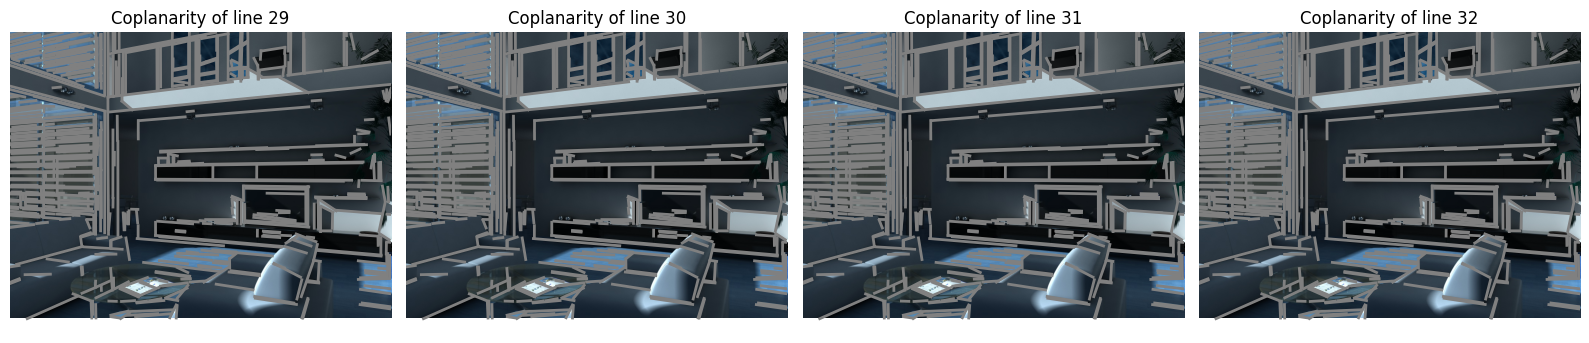

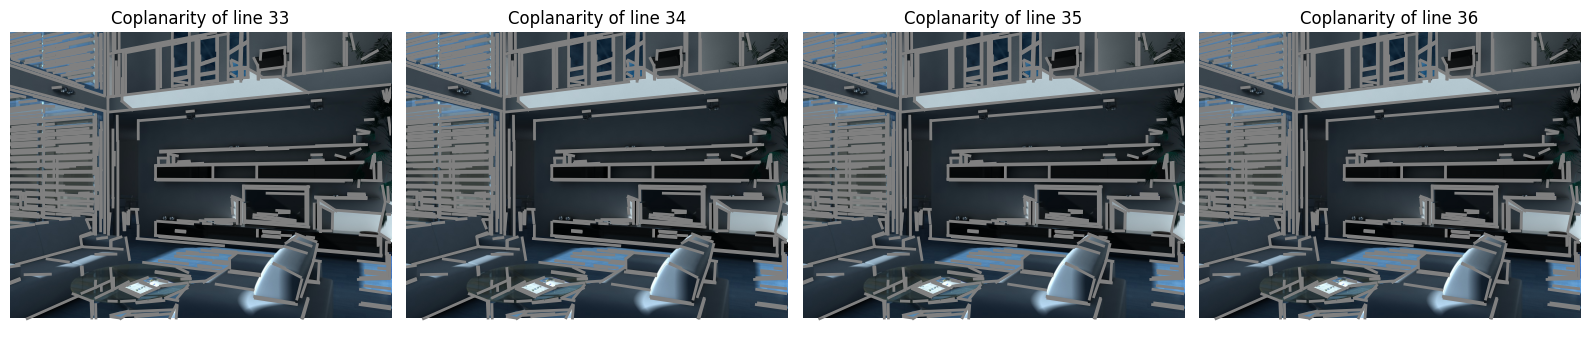

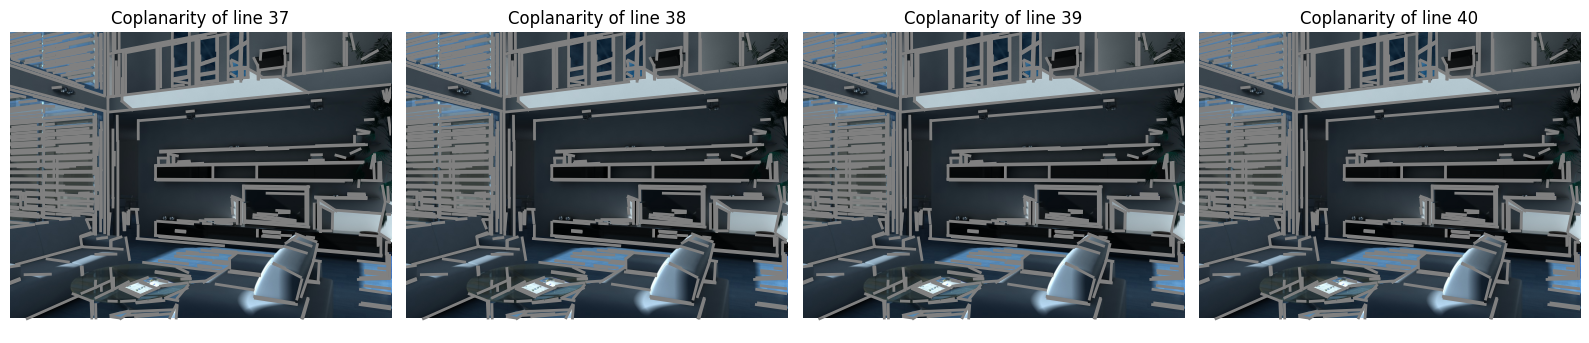

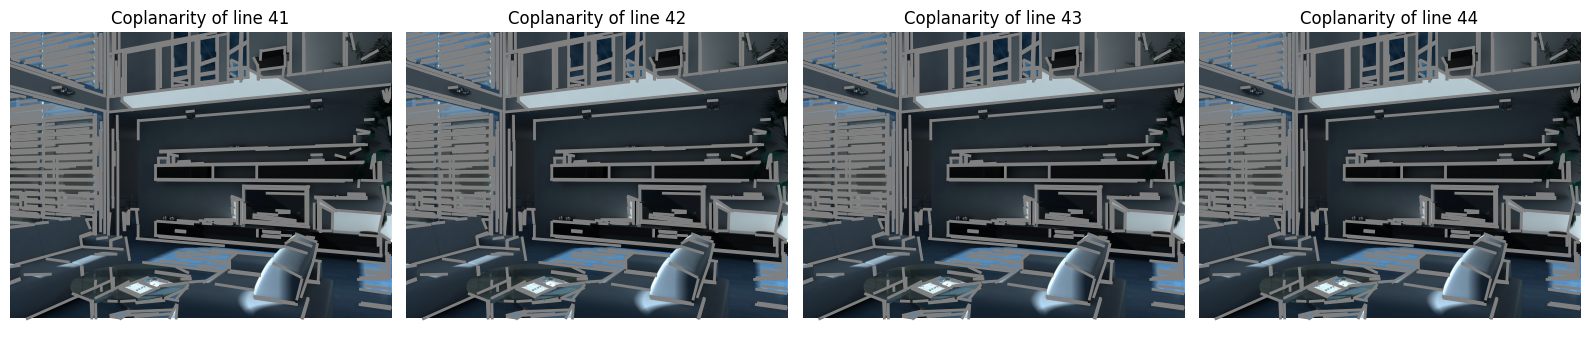

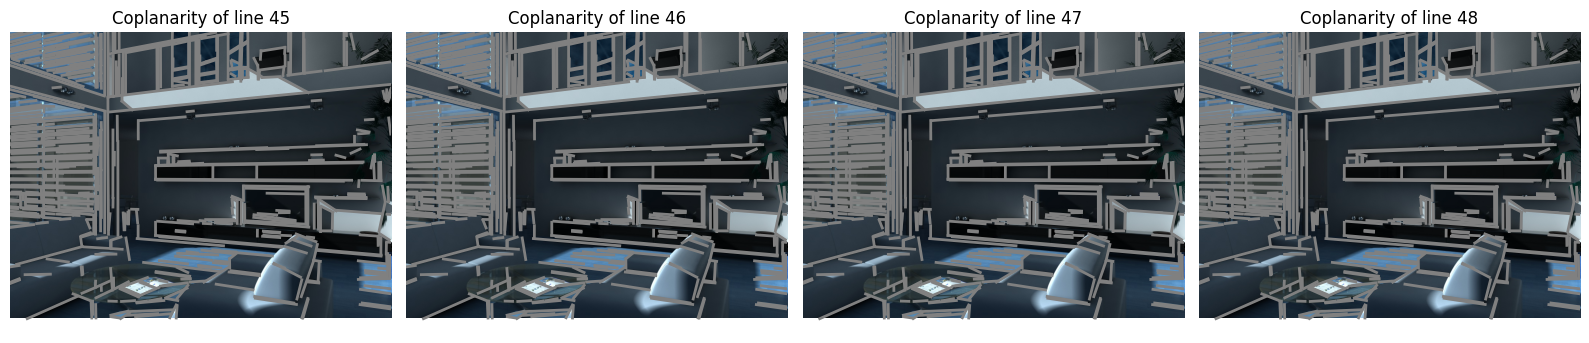

KeyboardInterrupt: 

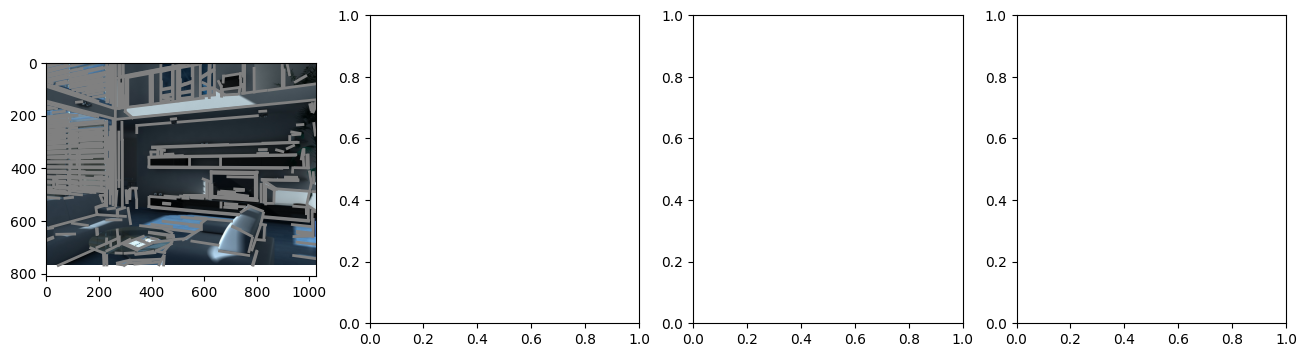

In [15]:
import matplotlib.pyplot as plt
import math

# Parameters
batch_size = 4  # Number of subplots per figure
num_items = len(edge_preds_array)
num_batches = math.ceil(num_items / batch_size)

for batch in range(num_batches):
    start_idx = batch * batch_size
    end_idx = min(start_idx + batch_size, num_items)
    current_batch_size = end_idx - start_idx

    # Create subplots for this batch
    fig, axes = plt.subplots(nrows=1, ncols=current_batch_size, figsize=(4 * current_batch_size, 4))
    
    # Ensure axes is iterable
    if current_batch_size == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        idx = start_idx + i
        plot_coplanar_lines(ax, pred_lines, edge_preds_array[idx], color_img)
        ax.set_title(f'Coplanarity of line {idx + 1}')
    
    plt.tight_layout()
    plt.show()

